# Ternary Predicates: Triplet Comparison Learning

This notebook shows how to define and constrain a ternary predicate `Closer(A, P, N)` which captures the judgment that an anchor item `A` is more similar to a positive item `P` than to a negative item `N`.

By the end of this notebook, we will have seen:

1. How to define a ternary predicate with three separate variables
2. How to express antisymmetry and reference symmetry as logical constraints
3. How to express accuracy itself as a logical consistency check using `Equivalent`
4. Why models with more than two input arguments need lambda wrappers
5. How the constraints improve consistency relative to unconstrained training

It uses the same Gaussian cluster setup as the [Symmetry Constraints notebook](Symmetry%20Constraints.ipynb).

## Preliminaries

To get started, let us first get the standard preambles out of the way.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pysignet as psn


## The logic

The predicate `Closer(A, P, N)` represents the judgment that the anchor `A` is more similar to `P` than to `N`. We impose two constraints that any coherent notion of closeness should satisfy.

**Antisymmetry**: if `A` is closer to `P` than to `N`, then `A` cannot also be closer to `N` than to `P`.

$$\forall A, P, N:\; \text{Closer}(A, P, N) \leftrightarrow \neg\,\text{Closer}(A, N, P)$$

**Reference symmetry**: if `A` is closer to `P` than to `N`, then `P` is also closer to `A` than to `N`. The anchor and the positive item are interchangeable as the reference point.

$$\forall A, P, N:\; \text{Closer}(A, P, N) \leftrightarrow \text{Closer}(P, A, N)$$


In [2]:
Closer = psn.Symbol("Closer")
Label  = psn.Symbol("Label")
A, P, N = psn.Variable("A P N")
Y = psn.Variable("Y")

antisym_expr  = psn.Equivalent(Closer(A, P, N), psn.Not(Closer(A, N, P)))
ref_sym_expr  = psn.Equivalent(Closer(A, P, N), Closer(P, A, N))
accuracy_expr = psn.Equivalent(Closer(A, P, N), Label(Y))
constraints   = psn.And(antisym_expr, ref_sym_expr)

from IPython.display import Markdown

display(Markdown("### Antisymmetry"))
display(antisym_expr)

display(Markdown("### Reference symmetry"))
display(ref_sym_expr)

display(Markdown("### Accuracy (model agrees with ground truth)"))
display(accuracy_expr)

### Antisymmetry

Equivalent(Closer(A, P, N), ~Closer(A, N, P))

### Reference symmetry

Equivalent(Closer(A, P, N), Closer(P, A, N))

### Accuracy (model agrees with ground truth)

Equivalent(Closer(A, P, N), Label(Y))

## The model

A small MLP that takes three items concatenated together and outputs a score in [0, 1]. 


In [3]:
class TripletModel(nn.Module):
    def __init__(self, input_dim: int = 8, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim * 3, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid(),
        )

    def forward(self, a: torch.Tensor, p: torch.Tensor, n: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([a, p, n], dim=-1)).squeeze(-1)


## The data

We use the same Gaussian cluster setup: 800 items drawn from 10 clusters in 8-dimensional space. Two items are "closer" if they belong to the same cluster. (We could have defined closer in other ways too. For example, we could have actually used the Euclidean distance between points.)

`make_triplets` samples balanced triplets: half where the anchor and positive are from the same cluster (`Closer(A, P, N) = True`) and half where the anchor and negative are from the same cluster (`Closer(A, P, N) = False`). Balancing prevents the model from collapsing to always predicting one outcome.


In [4]:
torch.manual_seed(1)

n_items   = 800
n_classes = 10
input_dim = 8

centers    = torch.randn(n_classes, input_dim) * 3
labels_all = torch.randint(0, n_classes, (n_items,))
items_all  = centers[labels_all] + torch.randn(n_items, input_dim) * 0.5

train_items, test_items   = items_all[:600], items_all[600:]
train_labels, test_labels = labels_all[:600], labels_all[600:]


def make_triplets(
    items: torch.Tensor, labels: torch.Tensor, n_triplets: int
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Sample balanced triplets: half Closer=True, half Closer=False."""
    n_pos = n_triplets // 2
    n_neg = n_triplets - n_pos

    pos_ai, pos_pi, pos_ni = [], [], []
    neg_ai, neg_pi, neg_ni = [], [], []

    while len(pos_ai) < n_pos or len(neg_ai) < n_neg:
        i = torch.randint(0, len(items), (1,)).item()
        j = torch.randint(0, len(items), (1,)).item()
        k = torch.randint(0, len(items), (1,)).item()
        same_ij = labels[i] == labels[j]
        same_ik = labels[i] == labels[k]
        if same_ij and not same_ik and len(pos_ai) < n_pos:
            pos_ai.append(i); pos_pi.append(j); pos_ni.append(k)
        elif not same_ij and same_ik and len(neg_ai) < n_neg:
            neg_ai.append(i); neg_pi.append(j); neg_ni.append(k)

    idx_a = torch.tensor(pos_ai + neg_ai)
    idx_p = torch.tensor(pos_pi + neg_pi)
    idx_n = torch.tensor(pos_ni + neg_ni)
    a = items[idx_a]; p = items[idx_p]; n = items[idx_n]
    y = torch.cat([torch.ones(n_pos), torch.zeros(n_neg)])
    return a, p, n, y


a_test, p_test, n_test, y_test = make_triplets(test_items, test_labels, 1000)
test_loader = DataLoader(
    TensorDataset(a_test, p_test, n_test, y_test), batch_size=256, shuffle=False
)

print(f"Test triplets: {len(a_test)},  fraction Closer=True: {y_test.mean():.3f}")


Test triplets: 1000,  fraction Closer=True: 0.500


## The evaluator

We track three things: accuracy against ground truth labels, antisymmetry consistency, and reference symmetry consistency. The two constraint checks are label-free: they measure the internal consistency of the model's predictions regardless of ground truth.

Accuracy requires a label, and we express it as a consistency check too. The idea is to define a deterministic predicate `Label(Y)` that simply returns its input (the ground truth label in {0, 1}) and bind `Y` to the label tensor at evaluation time. Then the accuracy formula is:

$$Closer(A, P, N) \leftrightarrow Label(Y)$$

This expression is satisfied for a given triplet exactly when the model's prediction agrees with the ground truth: both True (model predicts positive, label is 1) or both False (model predicts negative, label is 0). Its consistency rate is accuracy.

In [5]:
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float, float]:
    pred = lambda a, p, n: model(a, p, n)
    acc_checker     = psn.consistency_report(accuracy_expr, {"Closer": pred, "Label": lambda y: y})
    antisym_checker = psn.consistency_report(antisym_expr,  {"Closer": pred})
    ref_sym_checker = psn.consistency_report(ref_sym_expr,  {"Closer": pred})

    for a, p, n, y in loader:
        acc_checker.eval(A=a, P=p, N=n, Y=y)
        antisym_checker.eval(A=a, P=p, N=n)
        ref_sym_checker.eval(A=a, P=p, N=n)

    return (
        acc_checker.global_consistency(),
        antisym_checker.global_consistency(),
        ref_sym_checker.global_consistency(),
    )

## The training functions

The unconstrained trainer uses only binary cross-entropy on labeled triplets. The constrained trainer follows the same warmup pattern as the previous notebooks: train without the constraint first to develop useful features, then switch to combined training.


In [6]:
def train_unconstrained(train_loader: DataLoader, n_epochs: int = 20,
                        lr: float = 0.001) -> nn.Module:
    model = TripletModel(input_dim=input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        model.train()
        for a, p, n, y in train_loader:
            optimizer.zero_grad()
            F.binary_cross_entropy(model(a, p, n), y).backward()
            optimizer.step()
    return model


def train_constrained(train_loader: DataLoader, n_epochs: int = 20,
                      warmup_epochs: int = 20, lr: float = 0.001,
                      constraint_weight: float = 1.0) -> nn.Module:
    model = TripletModel(input_dim=input_dim)

    # 1. Register the ternary predicate via a lambda
    predicates = {"Closer": lambda a, p, n: model(a, p, n)}

    # 2. Compile both constraints into a single loss generator
    constraint = psn.logic_to_loss(constraints, predicates)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(warmup_epochs):
        model.train()
        for a, p, n, y in train_loader:
            optimizer.zero_grad()
            F.binary_cross_entropy(model(a, p, n), y).backward()
            optimizer.step()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        for a, p, n, y in train_loader:
            optimizer.zero_grad()
            supervised_loss = F.binary_cross_entropy(model(a, p, n), y)

            # 3. Add the constraint loss
            sym_loss = constraint.loss(A=a, P=p, N=n)

            (supervised_loss + constraint_weight * sym_loss).backward()
            optimizer.step()

    return model


## Effect of training data size

For each training size we run 5 trials with different random samples of triplets. Model initialization is fixed across trials to isolate the effect of data variation. We report mean and standard error across trials.


In [7]:
n_trials    = 5
train_sizes = [10, 25, 50, 100, 250, 500]
model_seed  = 42

results_u = {n: {"acc": [], "antisym": [], "refsym": []} for n in train_sizes}
results_c = {n: {"acc": [], "antisym": [], "refsym": []} for n in train_sizes}

for n in train_sizes:
    for trial in range(n_trials):
        torch.manual_seed(trial)
        a_tr, p_tr, n_tr, y_tr = make_triplets(train_items, train_labels, n)
        loader = DataLoader(
            TensorDataset(a_tr, p_tr, n_tr, y_tr),
            batch_size=min(16, n), shuffle=True,
        )

        torch.manual_seed(model_seed)
        model_u = train_unconstrained(loader)
        acc_u, antisym_u, refsym_u = evaluate(model_u, test_loader)
        results_u[n]["acc"].append(acc_u)
        results_u[n]["antisym"].append(antisym_u)
        results_u[n]["refsym"].append(refsym_u)

        torch.manual_seed(model_seed)
        model_c = train_constrained(loader)
        acc_c, antisym_c, refsym_c = evaluate(model_c, test_loader)
        results_c[n]["acc"].append(acc_c)
        results_c[n]["antisym"].append(antisym_c)
        results_c[n]["refsym"].append(refsym_c)

    print(f"n={n:4d} done")


n=  10 done


n=  25 done


n=  50 done


n= 100 done


n= 250 done


n= 500 done


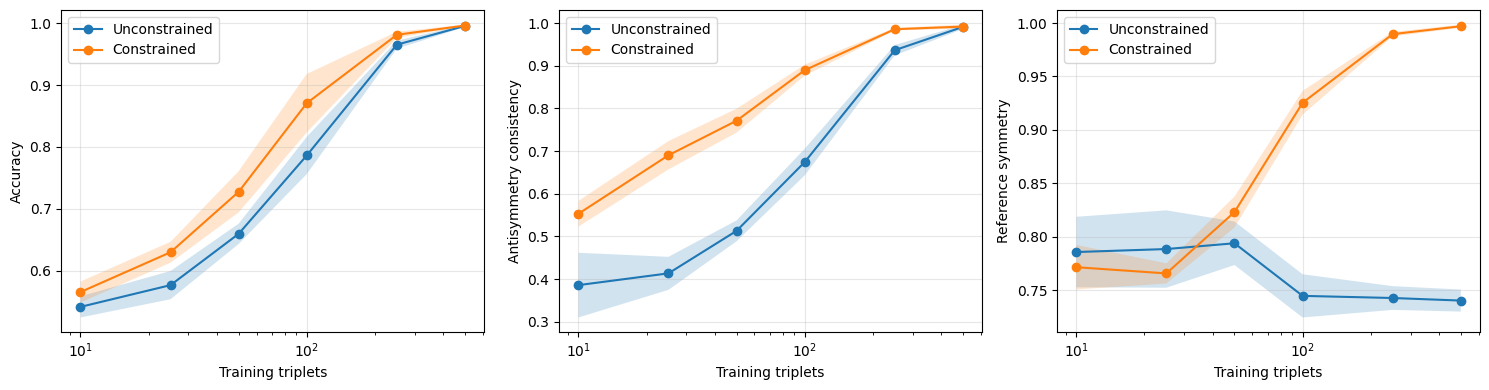

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ("acc",     "Accuracy",                axes[0]),
    ("antisym", "Antisymmetry consistency", axes[1]),
    ("refsym",  "Reference symmetry",       axes[2]),
]

for key, title, ax in configs:
    for label, res in [("Unconstrained", results_u), ("Constrained", results_c)]:
        means = np.array([np.mean(res[n][key]) for n in train_sizes])
        sems  = np.array([np.std(res[n][key], ddof=1) / np.sqrt(n_trials) for n in train_sizes])
        ax.plot(train_sizes, means, marker="o", label=label)
        ax.fill_between(train_sizes, means - sems, means + sems, alpha=0.2)
    ax.set_xlabel("Training triplets")
    ax.set_ylabel(title)
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The left panel shows accuracy: both models improve with more data, with the constrained model tending to do better at small training sizes. The middle and right panels show that the constrained model maintains substantially higher antisymmetry and reference symmetry consistency across all training sizes. The benefit of the constraints is largest when data is scarce.

A natural next step is to explore how the choice of compilation strategy affects training. See the [Custom Compilers notebook](Custom%20Compilers.ipynb).